Project Scenario

    Introduction

You have recently been hired as a Data Analyst at a global IT and consulting firm known for its expertise in IT solutions and experienced consultants. To remain competitive in a rapidly changing technology environment, your organization regularly analyzes data to identify new and upcoming skill requirements.

    Roles and Responsibilities:

As a Data Analyst, you will contribute to this initiative by gathering data from various sources and identifying trends for this year’s In-Demand Skills Report.
One key source for your analysis will be the latest Developer Survey, a comprehensive dataset that offers insights into the global developer community.
Your initial task is to collect data on the most in-demand programming skills from a variety of sources, including:
    Job postings
    Learning portals
Developer surveys, such as the latest Stack Overflow Developer Survey
Once you have collected enough data, you will analyze it to uncover key findings and trends. Some of the trends you will
investigate include:
    What programming languages ​​are in the most demand?
    What database technologies are currently in the most demand?
    What integrated development environments (IDEs) are the most popular?

You will start by scraping the web, accessing APIs, and working with datasets, such as the latest Stack Overflow Developer Survey, in a variety of formats, such as .csv files, Excel spreadsheets, and databases.

After collecting the data, you will apply data mining techniques to prepare it for analysis.
Once the data is prepared, you will apply statistical methods to analyze the data, uncovering key trends and findings. You will then synthesize your findings using IBM Cognos Analytics to create a dashboard that visualizes the results. Finally, you will share your findings through a presentation, showcasing your storytelling and data analysis skills.

In [4]:
#------------
#DATA collect
#------------

In [1]:
import pandas as pd
import json

In [2]:
import requests
api_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json'

def get_number_of_jobs_T(technology):
    response=requests.get(api_url)
    if response.status_code==200:
        data = response.json()
        count=0
        
        for job in data:
            skills=job['Key Skills']
            if technology.lower() in skills.lower():
                count +=1
        return technology, count
    else:
        return 'Error'

In [3]:
get_number_of_jobs_T("Python")

('Python', 1173)

In [5]:
def get_number_of_jobs_L(location):
    response=requests.get(api_url)
    if response.status_code==200:
        data=response.json()
        count=0
        
        for job in data:
            loca=job['Location']
            if location.lower() in loca.lower():
                count +=1
        return location, count
    else:
        return 'Error'

In [6]:
get_number_of_jobs_L('Los Angeles')

('Los Angeles', 640)

In [7]:
technologies=['C', 'C#', 'C++', 'Java', 'JavaScript', 'Python', 'Scala', 'Oracle', 'SQL Server', 'mysql', 'PostgreSQL', 'MongoDB']

In [8]:
from openpyxl import Workbook

In [10]:

wb=Workbook()
ws=wb.active
ws.append(['Tecnology', 'Number_of_Jobs'])

for tech in technologies:
    tech_name, num_jobs=get_number_of_jobs_T(tech)
    ws.append([tech_name, num_jobs])

wb.save('job-postings.xlsx')

In [12]:
technologies1=['C', 'C#', 'C++', 'Java', 'JavaScript', 'Python', 'Scala', 'Oracle', 'SQL Server', 'MySQL Server', 'PostgreSQL', 'MongoDB']
wb=Workbook()
ws=wb.active
ws.append(['Tecnology', 'Number_of_Jobs'])

for tech in technologies:
    tech_name, num_jobs=get_number_of_jobs_T(tech)
    ws.append([tech_name, num_jobs])

wb.save('job-postings1.xlsx')

In [13]:
url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html'

In [14]:
from bs4 import BeautifulSoup
import requests
import csv

In [15]:
data=requests.get(url).text
soup=BeautifulSoup(data, 'html.parser')
table=soup.find('table')
with open('popular-languages.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Language', 'Average Annual Salary'])
    for row in table.find_all('tr')[1:]:
        cols=row.find_all('td')
        lang_name=cols[1].getText()
        avg_sal=cols[3].getText()
        writer.writerow([lang_name, avg_sal])
        print("{}--->{}".format(lang_name, avg_sal))

Python--->$114,383
Java--->$101,013
R--->$92,037
Javascript--->$110,981
Swift--->$130,801
C++--->$113,865
C#--->$88,726
PHP--->$84,727
SQL--->$84,793
Go--->$94,082


In [120]:
file_path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv'

In [121]:
df=pd.read_csv(file_path)

In [122]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [123]:
print(df.shape)

(65457, 114)


In [124]:
print(df.dtypes.reset_index())

                   index        0
0             ResponseId    int64
1             MainBranch   object
2                    Age   object
3             Employment   object
4             RemoteWork   object
..                   ...      ...
109      JobSatPoints_11  float64
110         SurveyLength   object
111           SurveyEase   object
112  ConvertedCompYearly  float64
113               JobSat  float64

[114 rows x 2 columns]


In [125]:
mean_age = pd.to_numeric(df['Age'].str.extract(r'(\d+)')[0]).mean()
print(mean_age)

29.08298149996162


In [126]:
df['Country'].unique()

array(['United States of America',
       'United Kingdom of Great Britain and Northern Ireland', 'Canada',
       'Norway', 'Uzbekistan', 'Serbia', 'Poland', 'Philippines',
       'Bulgaria', 'Switzerland', 'India', 'Germany', 'Ireland', 'Italy',
       'Ukraine', 'Australia', 'Brazil', 'Japan', 'Austria',
       'Iran, Islamic Republic of...', 'France', 'Saudi Arabia',
       'Romania', 'Turkey', 'Nepal', 'Algeria', 'Sweden', 'Netherlands',
       'Croatia', 'Pakistan', 'Czech Republic',
       'Republic of North Macedonia', 'Finland', 'Slovakia',
       'Russian Federation', 'Greece', 'Israel', 'Belgium', 'Mexico',
       'United Republic of Tanzania', 'Hungary', 'Argentina', 'Portugal',
       'Sri Lanka', 'Latvia', 'China', 'Singapore', 'Lebanon', 'Spain',
       'South Africa', 'Lithuania', 'Viet Nam', 'Dominican Republic',
       'Indonesia', 'Kosovo', 'Morocco', 'Taiwan', 'Georgia',
       'San Marino', 'Tunisia', 'Bangladesh', 'Nigeria', 'Liechtenstein',
       'Denmark', 'Ecu

In [127]:
len(df['Country'].unique())

186

In [128]:
#--------------
#DATA Wrangling
#--------------

In [129]:
#Find and Remove Duplicate

In [130]:
df.duplicated().sum()

np.int64(20)

In [131]:
df[df.duplicated()].head(20)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
65442,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65443,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
65444,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
65445,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
65446,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


In [132]:
df[df.duplicated(subset=['MainBranch', 'Employment', 'RemoteWork'], keep=False)].sort_values('ResponseId')

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [133]:
dup=df[df.duplicated(subset=['MainBranch', 'Employment', 'RemoteWork'], keep=False)]
dup_group=(dup.groupby(['Country', 'Employment']).size().reset_index(name='Count'))
top_c=dup_group.sort_values('Count', ascending=False).head(10)

In [134]:
import matplotlib.pyplot as plt

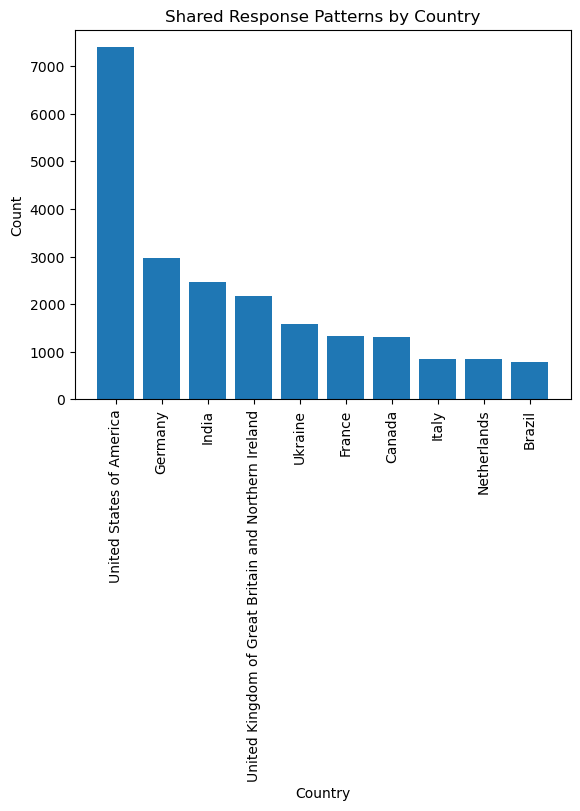

In [135]:
plt.figure()
plt.bar(top_c['Country'], top_c['Count'])
plt.xticks(rotation=90)
plt.title("Shared Response Patterns by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [136]:
df['ResponseId'].nunique()

65437

In [137]:
len(df)

65457

The column that defines record uniqueness is ResponseId, as each row represents a single respondent. Removing duplicates based on a subset of survey response columns (e.g., MainBranch, Employment, RemoteWork) would be inappropriate because different respondents may legitimately share identical responses. Therefore, duplicate removal should only be based on unique identifiers such as ResponseId, not on response patterns.

In [138]:
df.drop_duplicates(subset=['ResponseId'], inplace=True)

In [139]:
df.duplicated().sum()

np.int64(0)

In [140]:
#Find and Fill Missing DATA

In [141]:
missing_data=df.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print('')

ResponseId
ResponseId
False    65437
Name: count, dtype: int64

MainBranch
MainBranch
False    65437
Name: count, dtype: int64

Age
Age
False    65437
Name: count, dtype: int64

Employment
Employment
False    65437
Name: count, dtype: int64

RemoteWork
RemoteWork
False    54806
True     10631
Name: count, dtype: int64

Check
Check
False    65437
Name: count, dtype: int64

CodingActivities
CodingActivities
False    54466
True     10971
Name: count, dtype: int64

EdLevel
EdLevel
False    60784
True      4653
Name: count, dtype: int64

LearnCode
LearnCode
False    60488
True      4949
Name: count, dtype: int64

LearnCodeOnline
LearnCodeOnline
False    49237
True     16200
Name: count, dtype: int64

TechDoc
TechDoc
False    40897
True     24540
Name: count, dtype: int64

YearsCode
YearsCode
False    59869
True      5568
Name: count, dtype: int64

YearsCodePro
YearsCodePro
False    51610
True     13827
Name: count, dtype: int64

DevType
DevType
False    59445
True      5992
Name: count, dty

In [142]:
import seaborn as sns

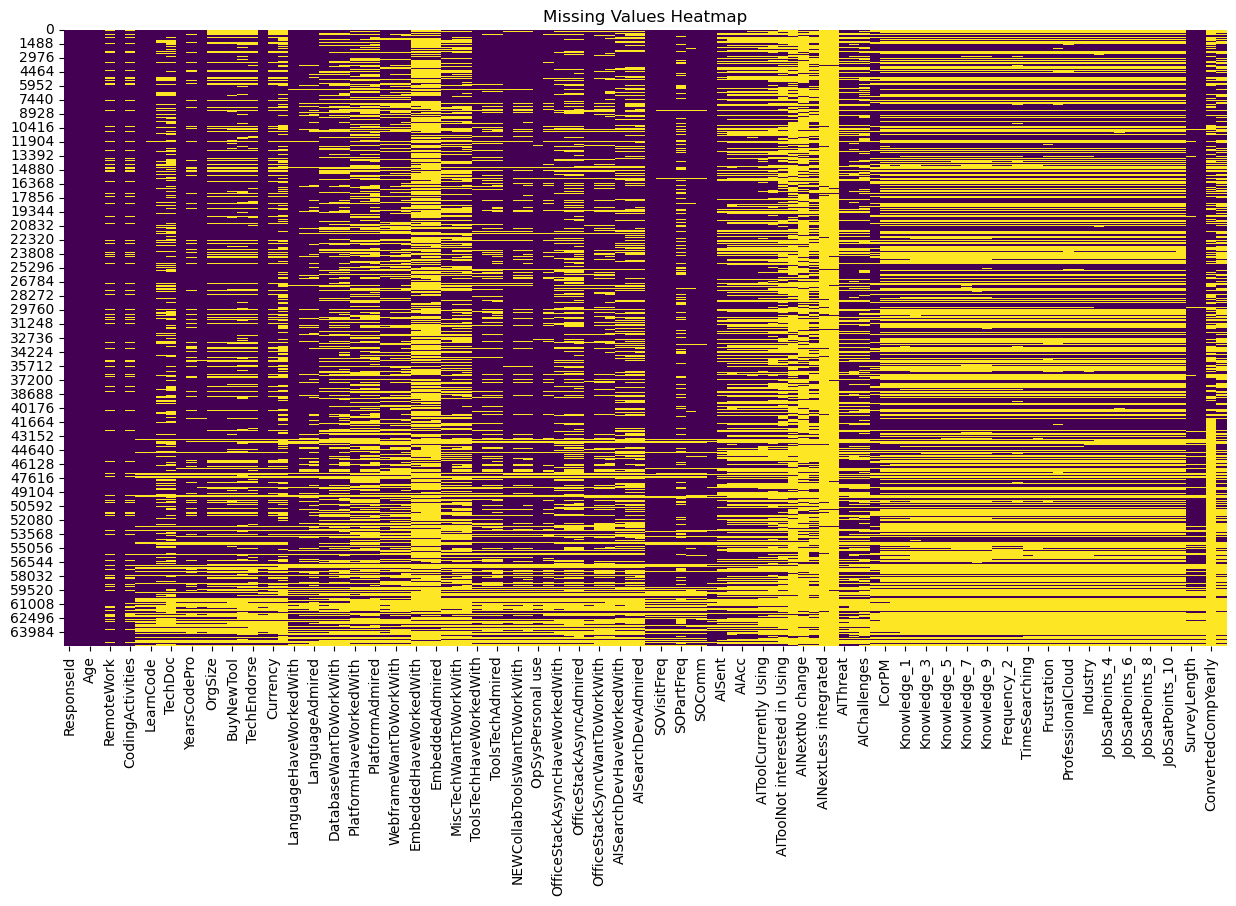

In [143]:
plt.figure(figsize=(15,8))
sns.heatmap(missing_data, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [144]:
frq_ed=df['EdLevel'].value_counts().idxmax()
df['EdLevel']=df['EdLevel'].fillna(frq_ed)

In [145]:
df['EdLevel'].isnull().sum()

np.int64(0)

In [146]:
avg_comp_tot=df['CompTotal'].astype('float').median(axis=0)
avg_conv=df['ConvertedCompYearly'].astype('float').median(axis=0)

df['CompTotal']=df['CompTotal'].fillna(avg_comp_tot)
df['ConvertedCompYearly']=df['ConvertedCompYearly'].fillna(avg_conv)

In [147]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

In [148]:
df['CompTotal'].isnull().sum()

np.int64(0)

In [149]:
df['CompTotal_norm']=df['CompTotal']/df['CompTotal'].max()
df['ConvertedCompYearly_norm']=df['ConvertedCompYearly']/df['ConvertedCompYearly'].max()

In [150]:
frq_rw=df['RemoteWork'].value_counts().idxmax()
df['RemoteWork']=df['RemoteWork'].fillna(frq_rw)

In [151]:
df['RemoteWork'].isnull().sum()

np.int64(0)

In [152]:
[col for col in df.columns if 'Comp' in col]

['CompTotal',
 'AIComplex',
 'ConvertedCompYearly',
 'CompTotal_norm',
 'ConvertedCompYearly_norm']

In [153]:
df.loc[df['CompTotal'] < 500000, ['CompTotal', 'ConvertedCompYearly']].describe()

,CompTotal,ConvertedCompYearly
count,59230.000000,59230.000000
mean,111167.925089,71578.455242
std,62040.389322,39336.922696
min,0.000000,1.000000
25%,95000.000000,65000.000000
50%,110000.000000,65000.000000
75%,110000.000000,65000.000000
max,498000.000000,573245.000000


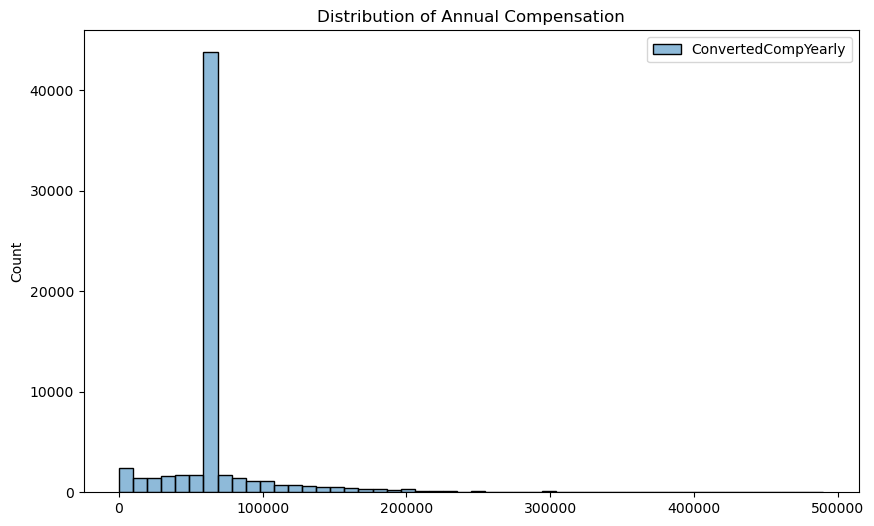

In [154]:
plt.figure(figsize=(10,6))
sns.histplot(df.loc[df['ConvertedCompYearly'] < 500000,['ConvertedCompYearly']], bins=50)
plt.title("Distribution of Annual Compensation")
plt.show()

In [155]:
frq_ca=df['CodingActivities'].value_counts().idxmax()
df['CodingActivities']=df['CodingActivities'].fillna(frq_ca)

In [156]:
df['CodingActivities'].isnull().sum()

np.int64(0)

In [157]:
#Normialize DATA

In [158]:
min_val=df['ConvertedCompYearly'].min() 
max_val=df['ConvertedCompYearly'].max()

df['ConvertedCompYearly_MinMax']=((df['ConvertedCompYearly']-min_val)/(max_val-min_val))

In [159]:
df['ConvertedCompYearly_MinMax'].describe()

count    65437.000000
mean         0.004464
std          0.006903
min          0.000000
25%          0.003998
50%          0.003998
75%          0.003998
max          1.000000
Name: ConvertedCompYearly_MinMax, dtype: float64

In [160]:
mean_val=df['ConvertedCompYearly'].mean()
std_val=df['ConvertedCompYearly'].std()

df['ConvertedCompYearly_Zscore']=((df['ConvertedCompYearly']-mean_val)/std_val)
df['ConvertedCompYearly_Zscore'].describe()

count    6.543700e+04
mean    -6.949392e-17
std      1.000000e+00
min     -6.467200e-01
25%     -6.751303e-02
50%     -6.751303e-02
75%     -6.751303e-02
max      1.442161e+02
Name: ConvertedCompYearly_Zscore, dtype: float64

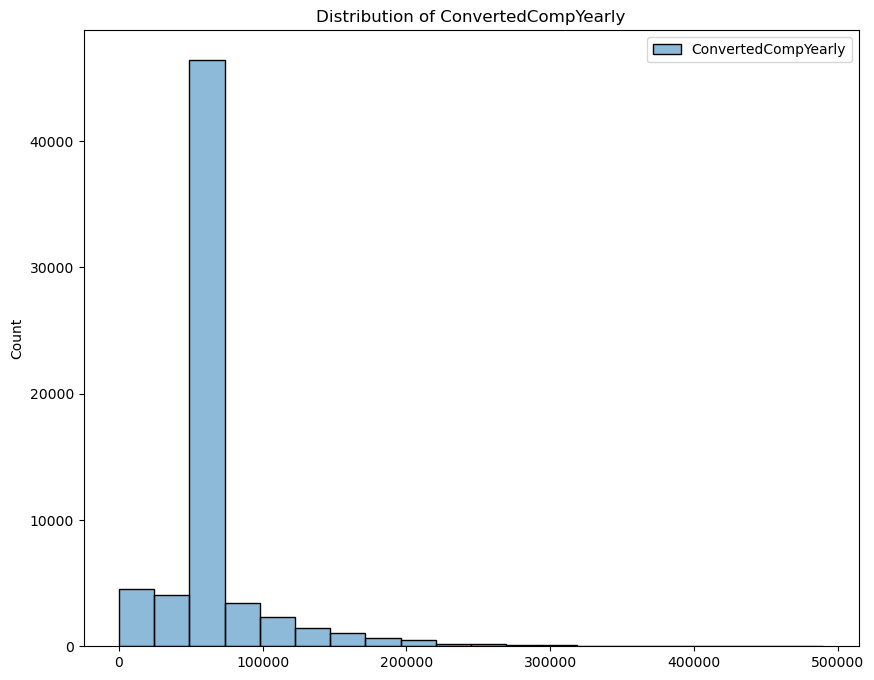

In [161]:
plt.figure(figsize=(10,8))
sns.histplot(df.loc[df['ConvertedCompYearly'] < 500000,['ConvertedCompYearly']], bins=20)
plt.title('Distribution of ConvertedCompYearly')
plt.show()

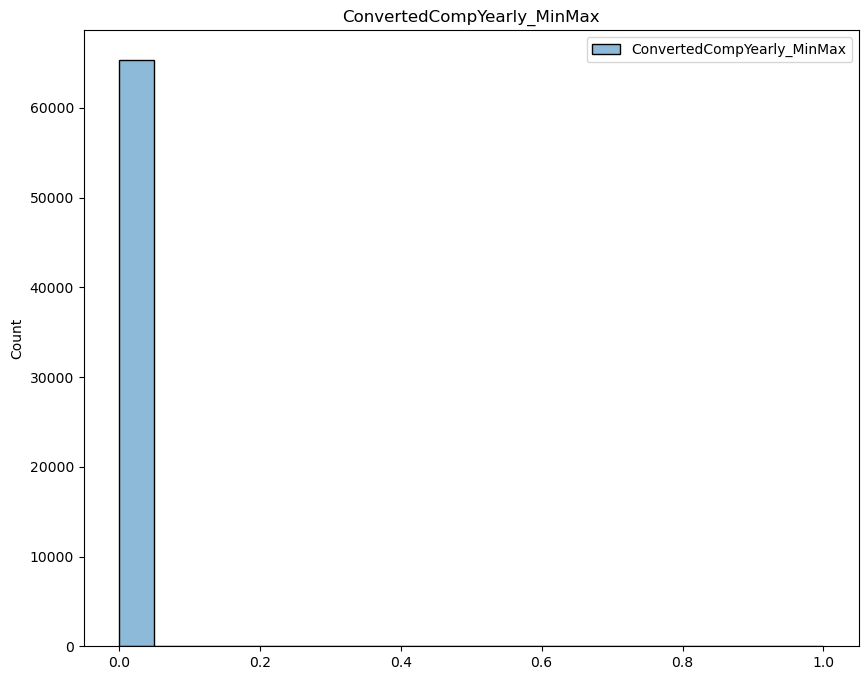

In [162]:
plt.figure(figsize=(10,8))
sns.histplot(df.loc[df['ConvertedCompYearly_MinMax']>0,['ConvertedCompYearly_MinMax']], bins=20)
plt.title('ConvertedCompYearly_MinMax')
plt.show()

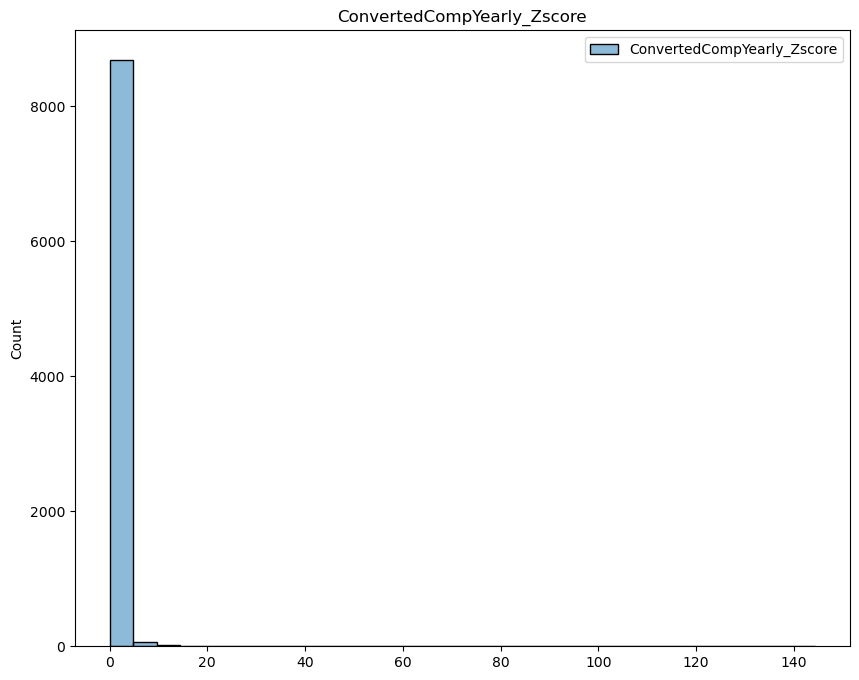

In [163]:
plt.figure(figsize=(10,8))
sns.histplot(df.loc[df['ConvertedCompYearly_Zscore']>0.1,['ConvertedCompYearly_Zscore']], bins=30)
plt.title('ConvertedCompYearly_Zscore')
plt.show()

In [164]:
#Finnish clean DATA

In [165]:
import numpy as np

In [166]:
df['ConvertedCompYearly_Log']=np.log1p(df['ConvertedCompYearly'])

In [167]:
df['ConvertedCompYearly_Log'].describe()

count    65437.000000
mean        10.976053
std          0.851456
min          0.693147
25%         11.082158
50%         11.082158
75%         11.082158
max         16.604010
Name: ConvertedCompYearly_Log, dtype: float64

In [168]:
print(df['YearsCodePro'].map(type).unique())

[<class 'float'> <class 'str'>]


In [169]:
df['YearsCodePro_Num'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})

In [170]:
avg_ycn=df['YearsCodePro_Num'].astype(float).median(axis=0)
df['YearsCodePro_Num']=df['YearsCodePro_Num'].fillna(avg_ycn)

In [171]:
df['YearsCodePro_Num'] = pd.to_numeric(df['YearsCodePro_Num'], errors='coerce')

In [172]:
def experience_level(years):
    if pd.isnull(years):
        return np.nan
    elif years < 2:
        return 'Junior'
    elif years < 5:
        return 'Mid-level'
    elif years < 10:
        return 'Senior'
    else:
        return 'Expert'

In [173]:
df['ExperienceLevel'] = df['YearsCodePro_Num'].apply(experience_level)

In [174]:
df[['YearsCodePro', 'YearsCodePro_Num', 'ExperienceLevel']].head(10)

,YearsCodePro,YearsCodePro_Num,ExperienceLevel
0,NaN,7.0,Senior
1,17,17.0,Expert
2,27,27.0,Expert
3,NaN,7.0,Senior
4,NaN,7.0,Senior
5,NaN,7.0,Senior
6,7,7.0,Senior
7,NaN,7.0,Senior
8,NaN,7.0,Senior
9,11,11.0,Expert


In [175]:
avg_js=df['JobSat'].astype(float).median(axis=0)
df['JobSat']=df['JobSat'].fillna(avg_js)
df['JobSat']=df['JobSat'].astype(int)

In [191]:
frq_lang=df['LanguageHaveWorkedWith'].value_counts().idxmax()
df['LanguageHaveWorkedWith']=df['LanguageHaveWorkedWith'].fillna(frq_lang)

In [219]:
frq_ind=df['Industry'].value_counts().idxmax()
df['Industry']=df['Industry'].fillna(frq_ind)

In [209]:
frq_langwant=df['LanguageWantToWorkWith'].value_counts().idxmax()
df['LanguageWantToWorkWith']=df['LanguageWantToWorkWith'].fillna(frq_langwant)

In [253]:
avg_we=df['WorkExp'].astype(float).median()
df['WorkExp']=df['WorkExp'].fillna(avg_we)

In [254]:
avg_js1=df['JobSatPoints_1'].astype(float).median()
df['JobSatPoints_1']=df['JobSatPoints_1'].fillna(avg_js1)

In [176]:
#--------------
#EDA
#--------------

In [177]:
bins=[0, 5, 10, 20, np.inf]
labels=['0-5', '5-10', '10-20', '20+'] 
df['ExperienceRange']=pd.cut(df['YearsCodePro_Num'], bins=bins, labels=labels)

In [178]:
median_sat=df.groupby('ExperienceRange')['JobSat'].median()
print(median_sat)

ExperienceRange
0-5      7.0
5-10     7.0
10-20    7.0
20+      7.0
Name: JobSat, dtype: float64


C:\Users\nazar\AppData\Local\Temp\ipykernel_9732\2664230184.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_sat=df.groupby('ExperienceRange')['JobSat'].median()


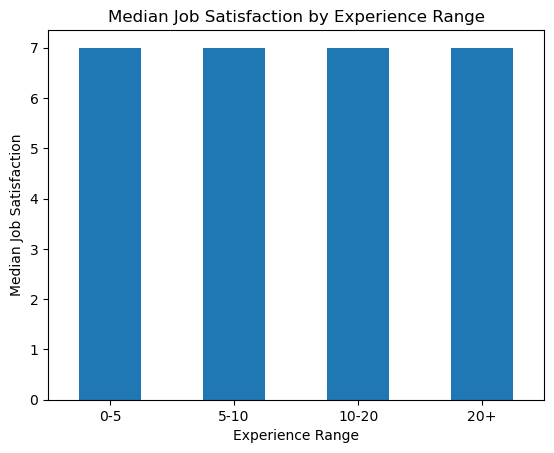

In [179]:
median_sat.plot(kind='bar')

plt.xlabel('Experience Range')
plt.ylabel('Median Job Satisfaction')
plt.title('Median Job Satisfaction by Experience Range')
plt.xticks(rotation=0)
plt.show()

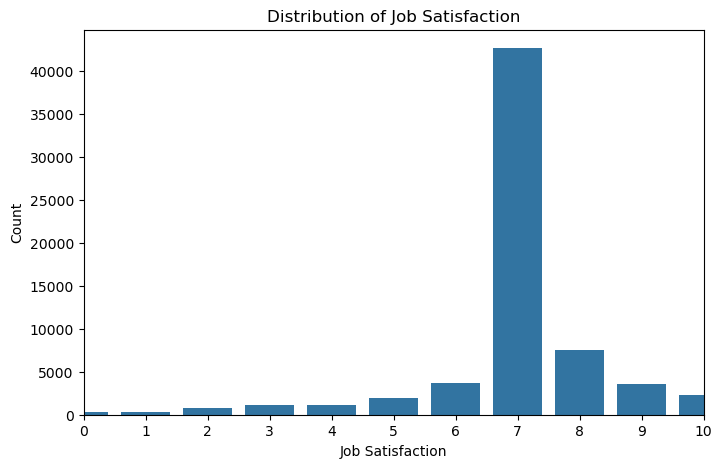

In [180]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSat', data=df)

plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Count')
plt.xlim(0.0, 10.0)
plt.show()

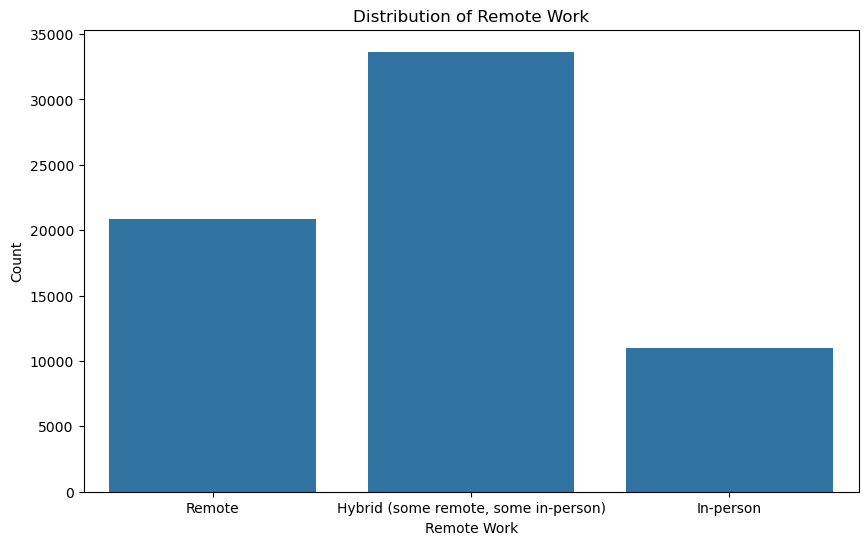

In [181]:
plt.figure(figsize=(10,6))
sns.countplot(x='RemoteWork', data=df)
plt.title('Distribution of Remote Work')
plt.xlabel('Remote Work')
plt.ylabel('Count')

plt.show()

In [183]:
df_clean = df[['Employment', 'RemoteWork']].copy()
df_clean['Employment'] = df_clean['Employment'].str.split(';')
df_clean = df_clean.explode('Employment')

remote_emp = pd.crosstab(df_clean['Employment'], df_clean['RemoteWork'])
remote_emp

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Employment,,,
"Employed, full-time",19706,9604,15852
"Employed, part-time",1922,1013,1210
I prefer not to say,546,0,0
"Independent contractor, freelancer, or self-employed",3492,901,6333
"Not employed, and not looking for work",1101,17,85
"Not employed, but looking for work",3449,73,432
Retired,599,21,61
"Student, full-time",7015,755,856
"Student, part-time",1591,496,569


In [184]:
df['DevType'].value_counts().head(10)

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Name: count, dtype: int64

In [186]:
remote_job=pd.crosstab(df['DevType'], df['RemoteWork']) 
remote_job

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
DevType,,,
Academic researcher,813,310,115
Blockchain,67,24,144
Cloud infrastructure engineer,300,52,282
Data engineer,564,138,416
Data or business analyst,277,123,123
Data scientist or machine learning specialist,586,153,285
Database administrator,78,43,50
Designer,101,24,57
DevOps specialist,549,102,368


In [188]:
df_clean2 = df[['Employment', 'DevType', 'RemoteWork']].copy()
df_clean2['Employment'] = df_clean2['Employment'].str.split(';')
df_clean2 = df_clean2.explode('Employment')

remote_emp_role = (
    df_clean2.groupby(['Employment','DevType','RemoteWork'])
      .size()
      .unstack(fill_value=0)
)

remote_emp_role

RemoteWork                                                Hybrid (some remote, some in-person)  \
Employment          DevType                                                                      
Employed, full-time Academic researcher                                                    407   
                    Blockchain                                                              24   
                    Cloud infrastructure engineer                                          250   
                    Data engineer                                                          472   
                    Data or business analyst                                               203   
...                                                                                        ...   
Student, part-time  Scientist                                                                6   
                    Security professional                                                   15   
                    Senior Executive (C-Suite, VP, etc.)                                     3   
                    Student                                                                337   
                    System administrator                                                    18   

RemoteWork                                                In-person  Remote  
Employment          DevType                                                  
Employed, full-time Academic researcher                         278      64  
                    Blockchain                                   16      95  
                    Cloud infrastructure engineer                49     249  
                    Data engineer                               127     351  
                    Data or business analyst                    109      87  
...                                                             ...     ...  
Student, part-time  Scientist                                     5       2  
                    Security professional                         4       4  
                    Senior Executive (C-Suite, VP, etc.)          1       3  
                    Student                                      38      33  
                    System administrator                         10       4  

[302 rows x 3 columns]

In [193]:
df['LanguageHaveWorkedWith'].value_counts().head(10)

LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript           6694
Python                                    832
HTML/CSS;JavaScript;PHP;SQL               503
HTML/CSS;JavaScript                       452
C#                                        452
Python;SQL                                441
Java                                      424
C#;HTML/CSS;JavaScript;SQL;TypeScript     408
JavaScript;TypeScript                     402
C#;HTML/CSS;JavaScript;SQL                357
Name: count, dtype: int64

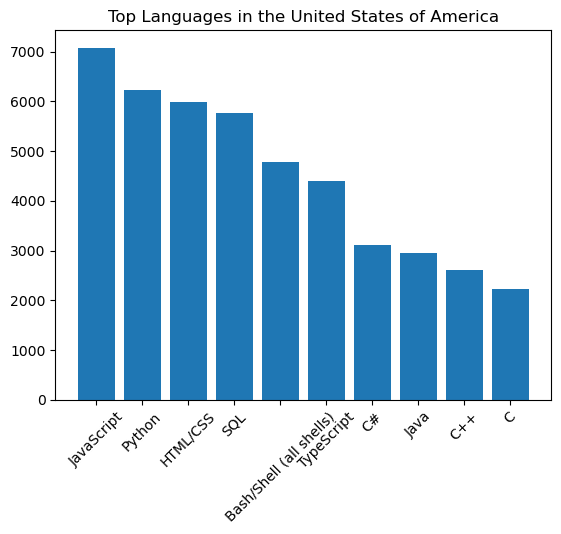

In [199]:
top_countries = df['Country'].value_counts().head(10).index
df_simple = df[df['Country'].isin(top_countries)].dropna(subset=['LanguageHaveWorkedWith']).copy()

df_simple = df_simple.assign(
    LanguageHaveWorkedWith=df_simple['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')
df_simple['LanguageHaveWorkedWith'] = df_simple['LanguageHaveWorkedWith'].str.strip()

language_counts = df_simple.groupby(['Country','LanguageHaveWorkedWith']).size().reset_index(name='Count')


top_langs = language_counts[language_counts['Country']=='United States of America'].sort_values('Count', ascending=False).head(10)
plt.bar(top_langs['LanguageHaveWorkedWith'], top_langs['Count'])
plt.xticks(rotation=45)
plt.title('Top Languages in the United States of America')
plt.show()

In [198]:
df[['YearsCodePro_Num', 'JobSat']].corr()

,YearsCodePro_Num,JobSat
YearsCodePro_Num,1.000000,0.069947
JobSat,0.069947,1.000000


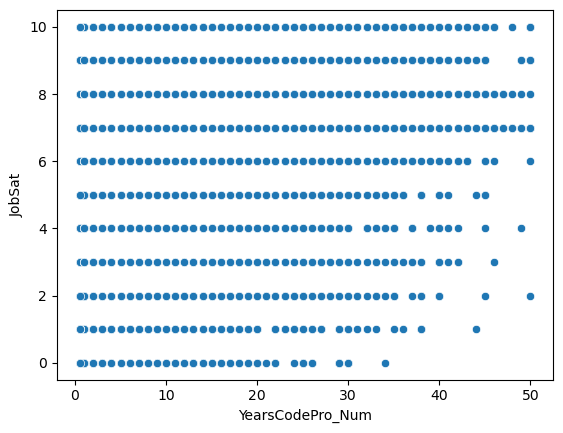

In [200]:
sns.scatterplot(data=df, x='YearsCodePro_Num', y='JobSat')
plt.show()

In [202]:
df_edu_emp=df[['EdLevel', 'Employment']].copy()
df_edu_emp['Employment']=df_edu_emp['Employment'].str.split(";")
df_edu_emp=df_edu_emp.explode('Employment')

edu_emp = pd.crosstab(df_edu_emp['EdLevel'], df_edu_emp['Employment'])
edu_emp

Employment,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
EdLevel,,,,,,,,,
"Associate degree (A.A., A.S., etc.)",1260,137,9,323,22,127,23,189,98
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",22098,1666,178,4399,336,1842,235,2821,1062
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",12489,753,53,2679,110,555,149,584,345
Primary/elementary school,201,79,51,159,155,114,12,583,90
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",2312,149,29,485,23,86,112,87,46
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",1860,623,92,902,338,528,24,2712,427
Some college/university study without earning a degree,4494,669,51,1634,174,618,107,1484,522
Something else,448,69,83,145,45,84,19,166,66


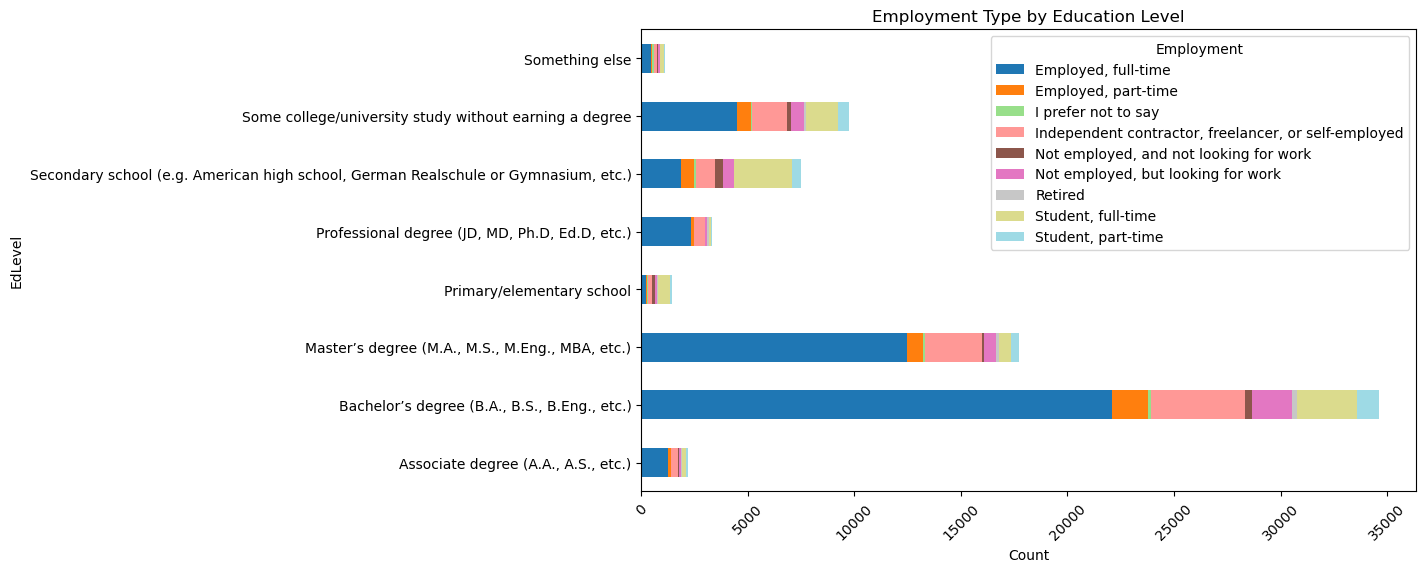

In [225]:
edu_emp.plot(kind='barh', stacked=True, figsize=(10,6), colormap='tab20')
plt.ylabel('EdLevel')
plt.xlabel('Count')
plt.title('Employment Type by Education Level')
plt.xticks(rotation=45)

plt.show()

In [215]:
#Distribution

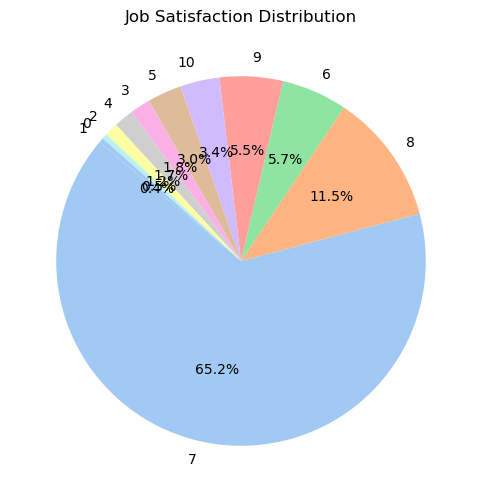

In [205]:
job_counts = df['JobSat'].value_counts(dropna=True)

plt.figure(figsize=(6,6))
plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Job Satisfaction Distribution')
plt.show()

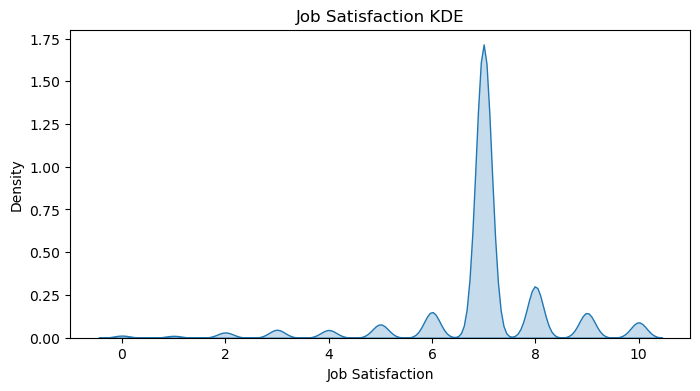

In [206]:
plt.figure(figsize=(8,4))
sns.kdeplot(df['JobSat'].dropna(), fill=True)
plt.title('Job Satisfaction KDE')
plt.xlabel('Job Satisfaction')
plt.ylabel('Density')
plt.show()

In [208]:
df['LanguageWantToWorkWith'].isnull().sum()

np.int64(9685)

In [210]:
df[['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']].describe(include='all')

,LanguageHaveWorkedWith,LanguageWantToWorkWith
count,65437,65437
unique,23864,22769
top,HTML/CSS;JavaScript;TypeScript,Python
freq,6694,10607


In [211]:
have_worked = df['LanguageHaveWorkedWith'].str.split(';').explode().str.strip()
want_work = df['LanguageWantToWorkWith'].str.split(';').explode().str.strip()

freq_have = have_worked.value_counts()
freq_want = want_work.value_counts()

top_languages = list(set(freq_have.head(10).index) | set(freq_want.head(10).index))

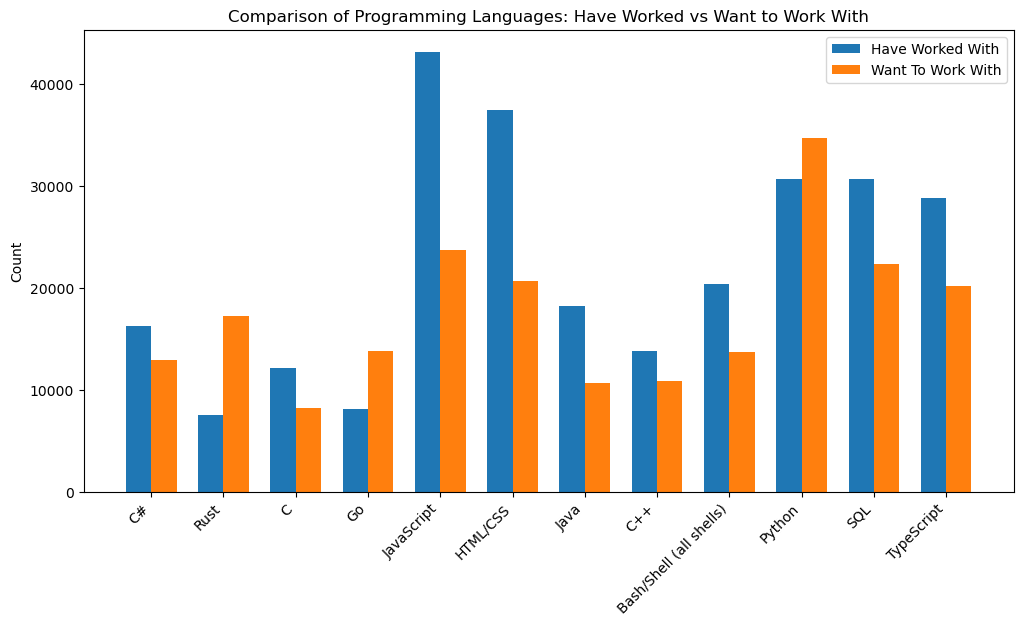

In [212]:
x = np.arange(len(top_languages))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, freq_have.reindex(top_languages, fill_value=0), width, label='Have Worked With')
plt.bar(x + width/2, freq_want.reindex(top_languages, fill_value=0), width, label='Want To Work With')

plt.xticks(x, top_languages, rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Comparison of Programming Languages: Have Worked vs Want to Work With')
plt.legend()
plt.show()

In [213]:
remote_counts = pd.crosstab(df['Country'], df['RemoteWork'])


top_co = df['Country'].value_counts().head(10).index
remote_counts = remote_counts.loc[top_co]

remote_counts

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Country,,,
United States of America,4857,1472,4766
Germany,3098,647,1202
India,2290,1088,853
United Kingdom of Great Britain and Northern Ireland,1765,307,1152
Ukraine,828,111,1733
France,1344,357,409
Canada,970,227,907
Poland,686,134,714
Netherlands,1028,240,181


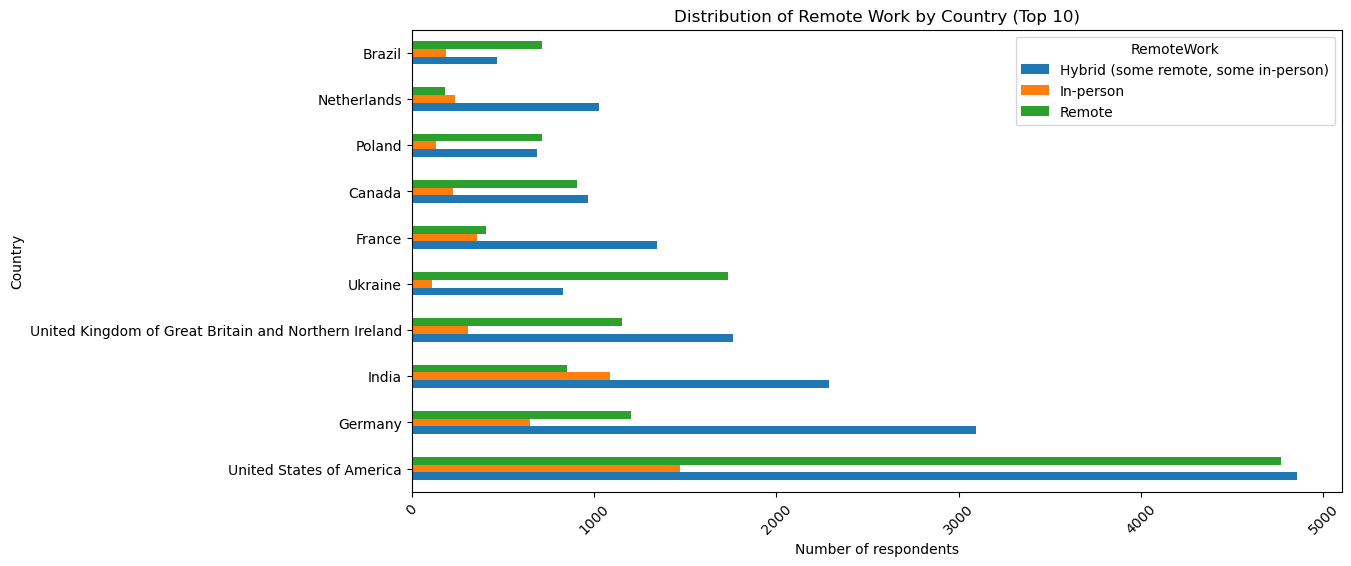

In [227]:
remote_counts.plot(kind='barh', figsize=(12,6))
plt.xlabel('Number of respondents')
plt.title('Distribution of Remote Work by Country (Top 10)')
plt.xticks(rotation=45)
plt.legend(title='RemoteWork')
plt.show()

In [218]:
#Outliers

In [221]:
ind_count=df['Industry'].value_counts().head(10)
ind_count

Industry
Software Development                          48497
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64

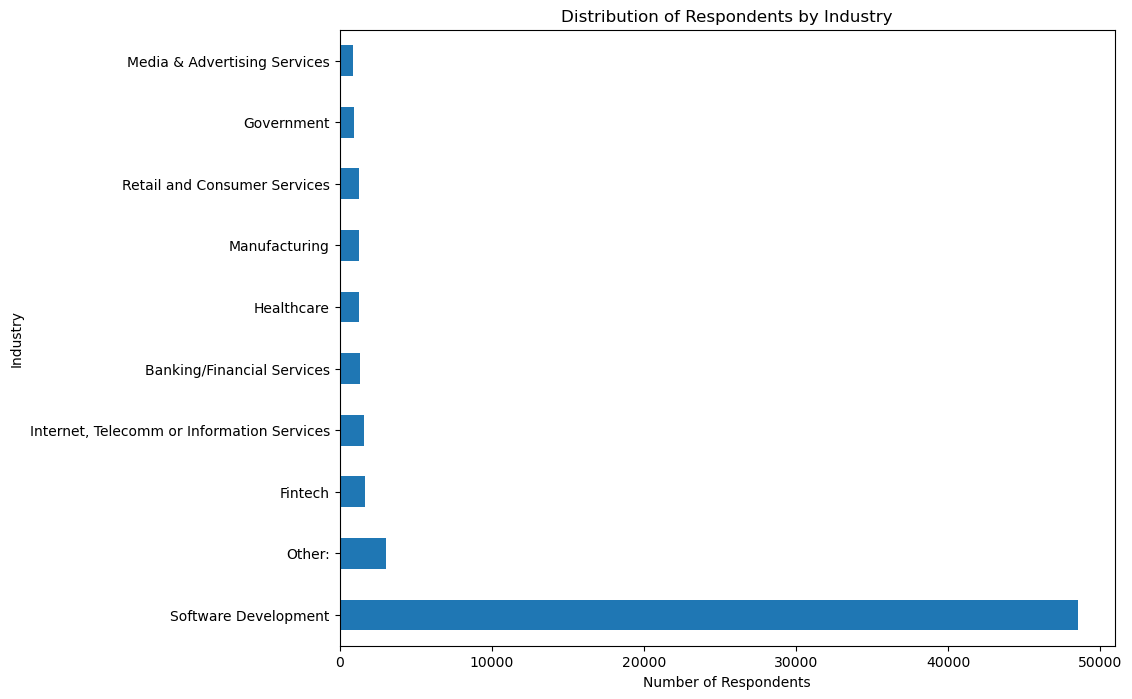

In [223]:
plt.figure(figsize=(10,8))
ind_count.plot(kind='barh')
plt.title('Distribution of Respondents by Industry')
plt.xlabel('Number of Respondents') 
plt.ylabel('Industry')


plt.show()

In [228]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

In [229]:
df['ConvertedCompYearly'].describe()

count    6.543700e+04
mean     7.257636e+04
std      1.122207e+05
min      1.000000e+00
25%      6.500000e+04
50%      6.500000e+04
75%      6.500000e+04
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [230]:
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("Mean:", mean_comp)
print("Median:", median_comp)
print("Std:", std_comp)

threshold = mean_comp + 3 * std_comp

outliers = df[df['ConvertedCompYearly'] > threshold]

print("Number of outliers:", len(outliers))

Mean: 72576.3582835399
Median: 65000.0
Std: 112220.68159729261
Number of outliers: 194


In [231]:
Q1=df['ConvertedCompYearly'].quantile(0.25) 
Q3=df['ConvertedCompYearly'].quantile(0.75)

IQR=Q3-Q1
IQR

np.float64(0.0)

In [232]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df['ConvertedCompYearly'] < lower_bound) | 
                  (df['ConvertedCompYearly'] > upper_bound)]

print("Number of outliers:", len(iqr_outliers))

Number of outliers: 23398


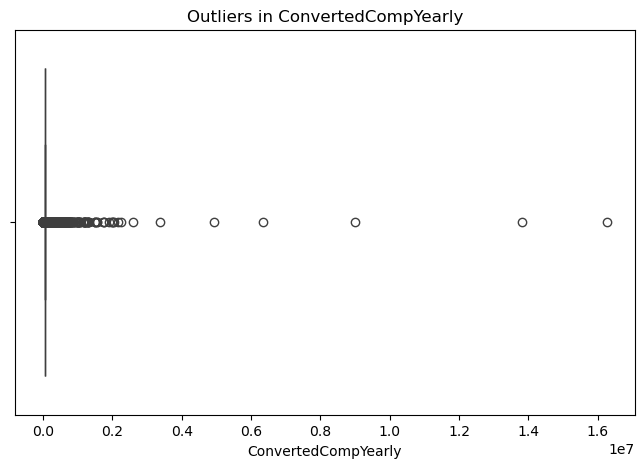

In [233]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Outliers in ConvertedCompYearly')
plt.show()

In [234]:
df_out = df[(df['ConvertedCompYearly'] >= lower_bound) & 
              (df['ConvertedCompYearly'] <= upper_bound)]
print("Original size:", df.shape)
print("New size:", df_out.shape)


Original size: (65437, 122)
New size: (42039, 122)


C:\Users\nazar\AppData\Local\Temp\ipykernel_9732\455387500.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['Age_num'] = df_out['Age'].map(age_map)


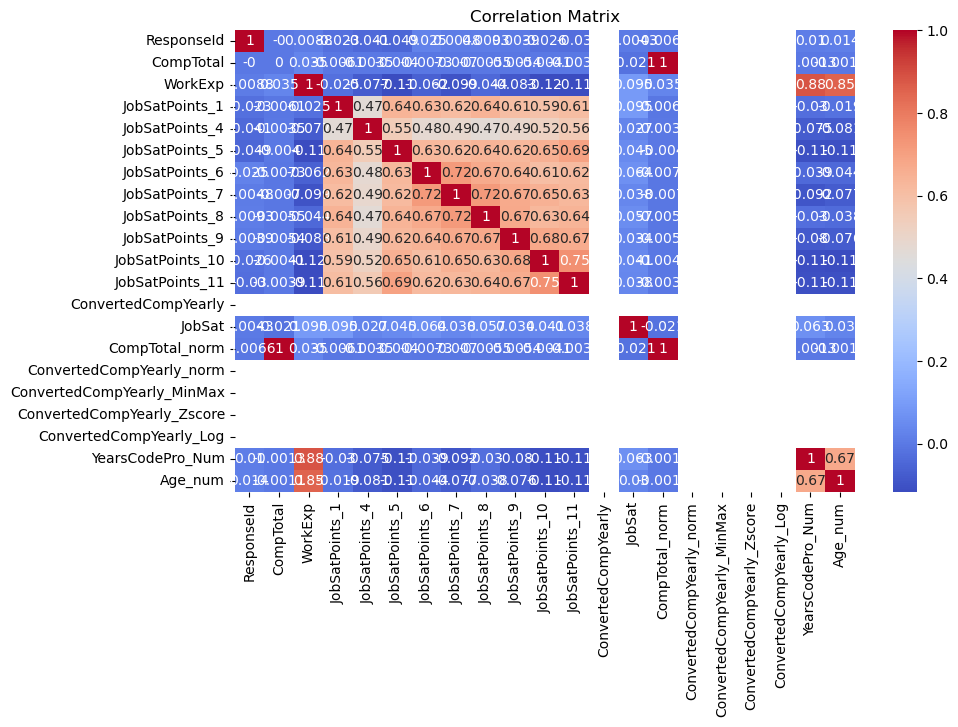

In [235]:
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_out['Age_num'] = df_out['Age'].map(age_map)
numeric_df = df_out.select_dtypes(include=['number'])
corr = numeric_df.corr()


plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [237]:
#Correlation

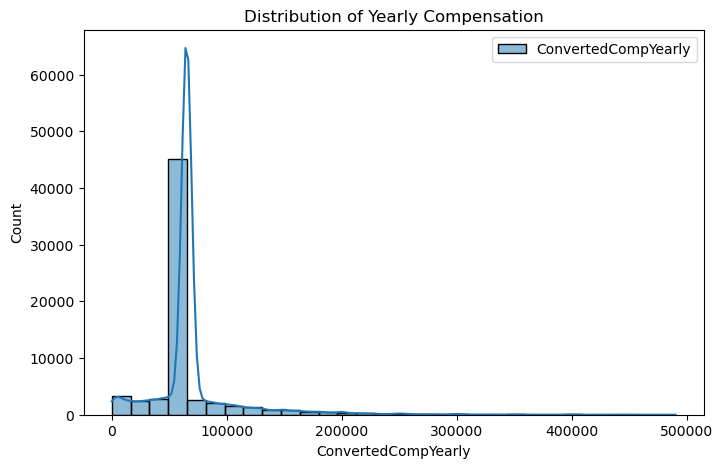

In [239]:
plt.figure(figsize=(8,5))

sns.histplot(df.loc[df['ConvertedCompYearly'] < 500000,['ConvertedCompYearly']], bins=30, kde=True)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('ConvertedCompYearly')

plt.show()

In [240]:
df[df['Employment'] == 'Employed, full-time']['ConvertedCompYearly'].median()

65000.0

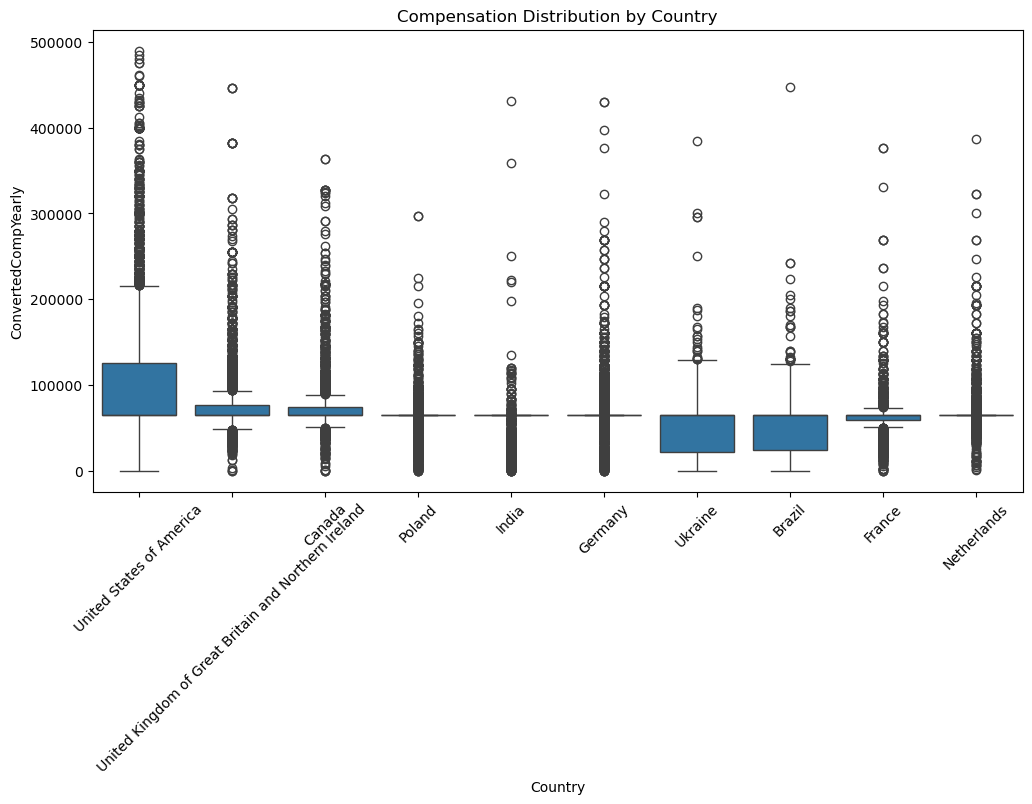

In [242]:
top_countries = df['Country'].value_counts().head(10).index
df_country = df[df['Country'].isin(top_countries)]

df_filtered = df_country[df_country['ConvertedCompYearly'] < 500000]

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Country',
    y='ConvertedCompYearly',
    data=df_filtered  
)

plt.xticks(rotation=45)
plt.title('Compensation Distribution by Country')

plt.show()

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.227932       -0.009370
WorkExp                         0.227932  1.000000        0.021219
JobSatPoints_1                 -0.009370  0.021219        1.000000


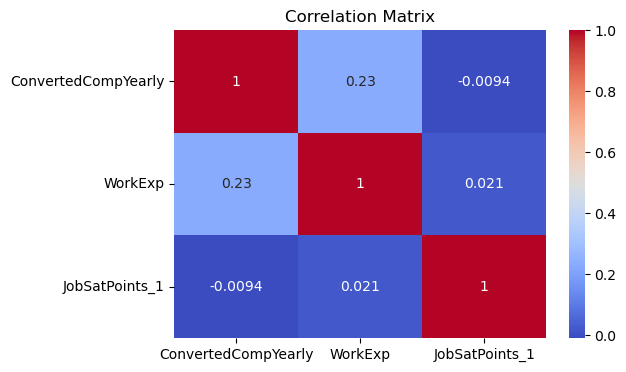

In [256]:
corr_data = df.loc[df['ConvertedCompYearly']<500000,['ConvertedCompYearly','WorkExp','JobSatPoints_1']]
corr_matrix = corr_data.corr()

print(corr_matrix)
plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

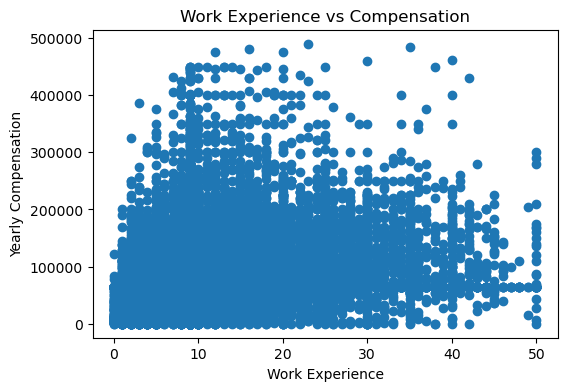

In [257]:
plt.figure(figsize=(6,4))

plt.scatter(corr_data['WorkExp'], corr_data['ConvertedCompYearly'])

plt.xlabel('Work Experience')
plt.ylabel('Yearly Compensation')
plt.title('Work Experience vs Compensation')

plt.show()


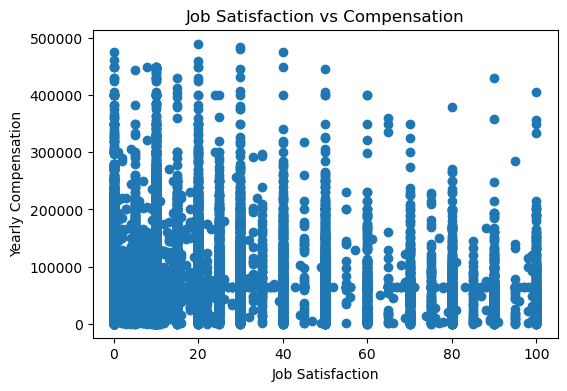

In [258]:
plt.figure(figsize=(6,4))

plt.scatter(corr_data['JobSatPoints_1'], corr_data['ConvertedCompYearly'])

plt.xlabel('Job Satisfaction')
plt.ylabel('Yearly Compensation')
plt.title('Job Satisfaction vs Compensation')

plt.show()


In [259]:
#-----------
#DATA VISUAL
#-----------

In [260]:
import sqlite3

In [261]:
conn=sqlite3.connect('survey_data.sqlite')

In [262]:
df.to_sql('main', conn, if_exists='replace', index=False)

65437

In [263]:
QUERY='SELECT * FROM main LIMIT 5'
df_check=pd.read_sql_query(QUERY, conn)
print(df_check)

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment                            RemoteWork   Check  \
0  Employed, full-time                                Remote  Apples   
1  Employed, full-time                                Remote  Apples   
2  Employed, full-time                                Remote  Apples   
3   Student, full-time  Hybrid (some remote, some in-person)  Apples   
4   Student, full-time  Hybrid (some remote, some in-person)  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source proje

In [264]:
QUERY='SELECT COUNT(*) FROM main'

df=pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,65437


In [265]:
QUERY="""
SELECT name as Table_Name FROM sqlite_master
WHERE type='table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


In [266]:
QUERY="""
SELECT Age, COUNT(*) as count 
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [267]:
QUERY="""
SELECT CompTotal FROM main
""" 
c_t=pd.read_sql_query(QUERY, conn)
c_t

,CompTotal
0,110000.0
1,110000.0
2,110000.0
3,110000.0
4,110000.0
...,...
65432,110000.0
65433,110000.0
65434,110000.0
65435,110000.0


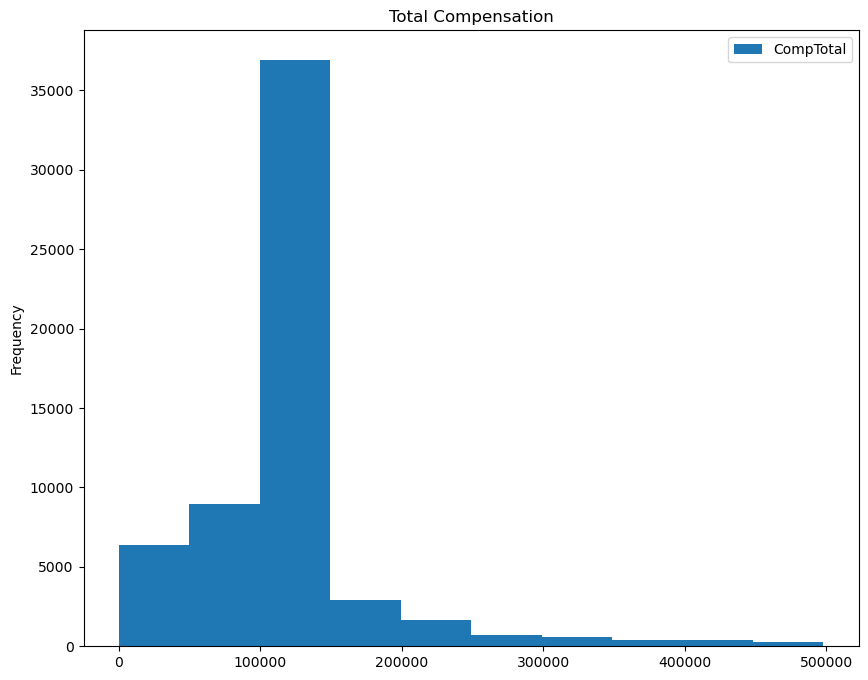

In [271]:
c_t.loc[c_t['CompTotal']<500000, ['CompTotal']].plot(kind='hist', bins=10, figsize=(10,8))
plt.title('Total Compensation')
plt.show()

In [273]:
QUERY="""
SELECT Age, COUNT(*) as count 
FROM main
GROUP BY Age
ORDER BY count DESC
"""
age=pd.read_sql_query(QUERY, conn) 
age.reset_index()
age

,Age,count
0,25-34 years old,23911
1,35-44 years old,14942
2,18-24 years old,14098
3,45-54 years old,6249
4,55-64 years old,2575
5,Under 18 years old,2568
6,65 years or older,772
7,Prefer not to say,322


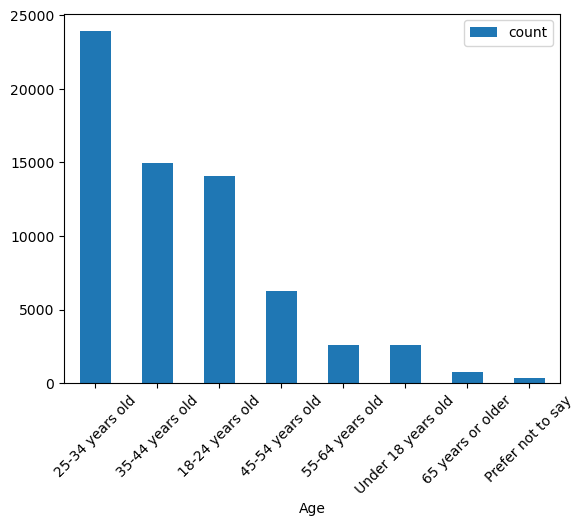

In [279]:
age.plot(kind='bar', x='Age', y='count')
plt.xticks(rotation=45)

plt.show()

In [276]:
QUERY = """
SELECT Age, WorkExp
FROM main
"""
age_w=pd.read_sql_query(QUERY, conn)
age_w

,Age,WorkExp
0,Under 18 years old,9.0
1,35-44 years old,17.0
2,45-54 years old,9.0
3,18-24 years old,9.0
4,18-24 years old,9.0
...,...,...
65432,18-24 years old,9.0
65433,25-34 years old,9.0
65434,25-34 years old,9.0
65435,18-24 years old,5.0


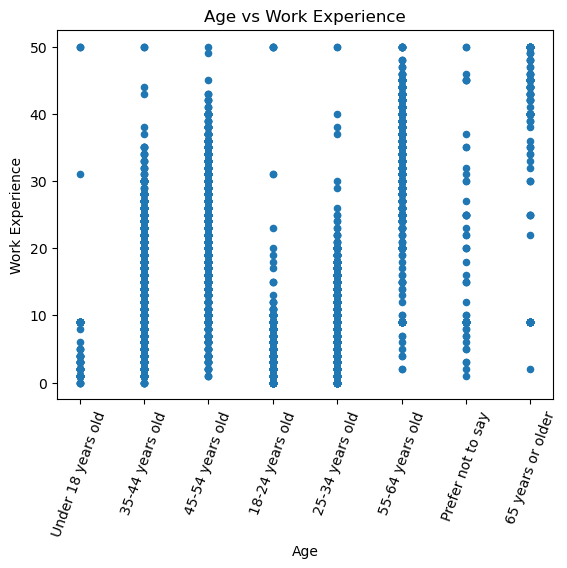

In [280]:
age_w.plot(kind='scatter', x='Age', y='WorkExp')
plt.xlabel('Age')
plt.ylabel('Work Experience')
plt.title('Age vs Work Experience')
plt.xticks(rotation=70)

plt.show()

In [281]:
QUERY="""
SELECT TimeSearching, Frustration, Age FROM main
""" 
tfa=pd.read_sql_query(QUERY, conn) 
tfa=tfa.dropna(subset=['Age'])
tfa=tfa.dropna(subset=['TimeSearching'])
tfa=tfa.dropna(subset=['Frustration'])
tfa

,TimeSearching,Frustration,Age
10,30-60 minutes a day,Amount of technical debt;Number of software to...,35-44 years old
12,30-60 minutes a day,Amount of technical debt;Complexity of tech st...,35-44 years old
15,60-120 minutes a day,Amount of technical debt;Complexity of tech st...,45-54 years old
18,15-30 minutes a day,Amount of technical debt;Tracking my work;Comp...,25-34 years old
20,Less than 15 minutes a day,Number of software tools in use;Tracking my wo...,25-34 years old
...,...,...,...
65241,60-120 minutes a day,Amount of technical debt;Showing my contributi...,25-34 years old
65265,60-120 minutes a day,Tracking my work;Complexity of tech stack for ...,18-24 years old
65268,Less than 15 minutes a day,None of these,25-34 years old
65351,15-30 minutes a day,Complexity of tech stack for deployment;Comple...,25-34 years old


In [282]:
age_map = {
'18-24 years old':21,
'25-34 years old':30,
'35-44 years old':40,
'45-54 years old':50,
'55-64 years old':60,
'65 or older':70
}
time_map = {
"Less than 15 minutes a day": 7,
"15-30 minutes a day": 22,
"30-60 minutes a day": 45,
"60-120 minutes a day": 90,
"Over 120 minutes a day": 150
}

tfa["TimeSearching_num"] = tfa["TimeSearching"].map(time_map)

tfa['Age_num'] = tfa['Age'].map(age_map)
tfa["Frustration"] = tfa["Frustration"].str.split(";")
tfa=tfa.explode('Frustration')

tfa

,TimeSearching,Frustration,Age,TimeSearching_num,Age_num
10,30-60 minutes a day,Amount of technical debt,35-44 years old,45,40.0
10,30-60 minutes a day,Number of software tools in use,35-44 years old,45,40.0
10,30-60 minutes a day,Tracking my work,35-44 years old,45,40.0
10,30-60 minutes a day,Showing my contributions,35-44 years old,45,40.0
12,30-60 minutes a day,Amount of technical debt,35-44 years old,45,40.0
...,...,...,...,...,...
65268,Less than 15 minutes a day,None of these,25-34 years old,7,30.0
65351,15-30 minutes a day,Complexity of tech stack for deployment,25-34 years old,22,30.0
65351,15-30 minutes a day,Complexity of tech stack for build,25-34 years old,22,30.0
65412,15-30 minutes a day,Amount of technical debt,35-44 years old,22,40.0


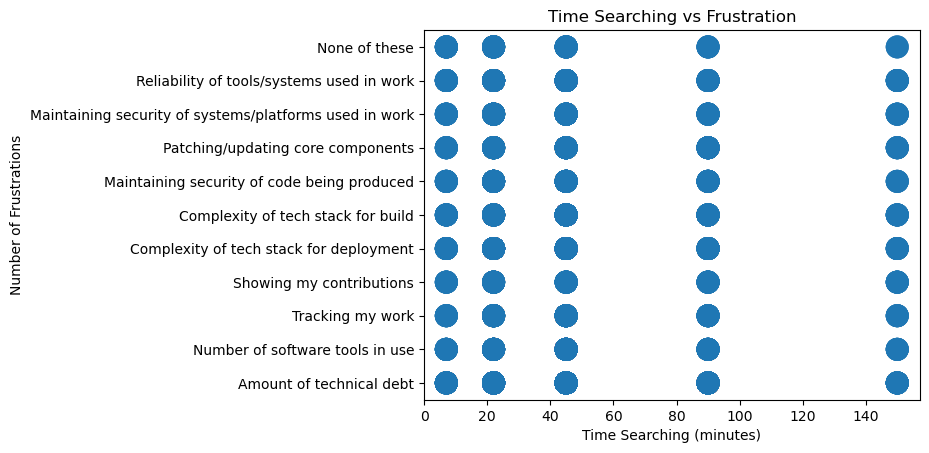

In [285]:
plt.scatter(
    tfa["TimeSearching_num"],
    tfa["Frustration"],
    s=tfa["Age_num"]*4,
    alpha=0.5
)

plt.xlabel("Time Searching (minutes)")
plt.ylabel("Number of Frustrations")
plt.title("Time Searching vs Frustration")

plt.show()


In [286]:
QUERY=""" 
SELECT ResponseId, DatabaseWantToWorkWith FROM main 
""" 
w_with = pd.read_sql_query(QUERY, conn)
w_with=w_with.dropna(subset=['DatabaseWantToWorkWith']) 
w_with['DatabaseWantToWorkWith']=w_with['DatabaseWantToWorkWith'].str.split(';')
w_with=w_with.explode('DatabaseWantToWorkWith')
w_with

,ResponseId,DatabaseWantToWorkWith
1,2,PostgreSQL
2,3,Firebase Realtime Database
3,4,MongoDB
3,4,MySQL
3,4,PostgreSQL
...,...,...
65435,65436,PostgreSQL
65435,65436,SQLite
65436,65437,MongoDB
65436,65437,MySQL


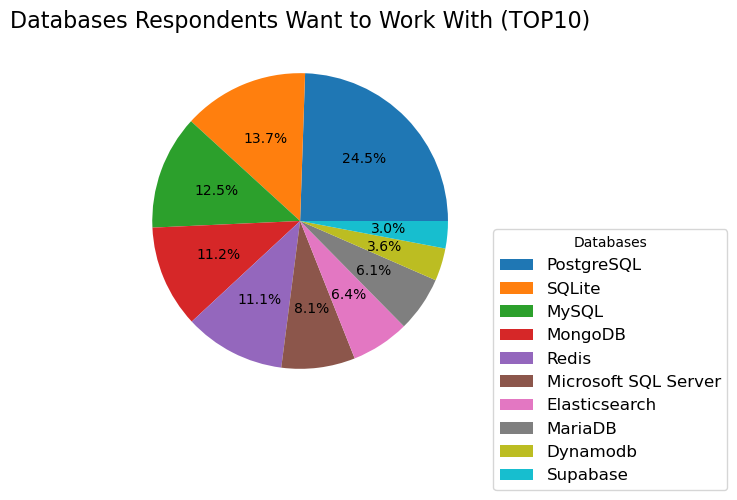

In [291]:
w_group=w_with.groupby('DatabaseWantToWorkWith')['ResponseId'].count().sort_values(ascending=False).head(10)

w_group.plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=None 
)

plt.legend(w_group.index, title='Databases', fontsize=12, bbox_to_anchor=(1, 0.5))
plt.ylabel('')
plt.title('Databases Respondents Want to Work With (TOP10)', fontsize=16)
plt.show()


In [292]:
QUERY="""
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE Age ='25-34 years old';
""" 
t_t=pd.read_sql_query(QUERY, conn)
t_t=t_t.dropna(subset=['TimeSearching', 'TimeAnswering'])
t_t

,Age,TimeSearching,TimeAnswering
1,25-34 years old,15-30 minutes a day,30-60 minutes a day
2,25-34 years old,Less than 15 minutes a day,15-30 minutes a day
3,25-34 years old,60-120 minutes a day,15-30 minutes a day
6,25-34 years old,60-120 minutes a day,15-30 minutes a day
8,25-34 years old,30-60 minutes a day,15-30 minutes a day
...,...,...,...
23805,25-34 years old,15-30 minutes a day,15-30 minutes a day
23806,25-34 years old,60-120 minutes a day,15-30 minutes a day
23836,25-34 years old,60-120 minutes a day,30-60 minutes a day
23842,25-34 years old,Less than 15 minutes a day,Less than 15 minutes a day


TimeSearching_num    45.0
TimeAnswering_num    22.0
dtype: float64


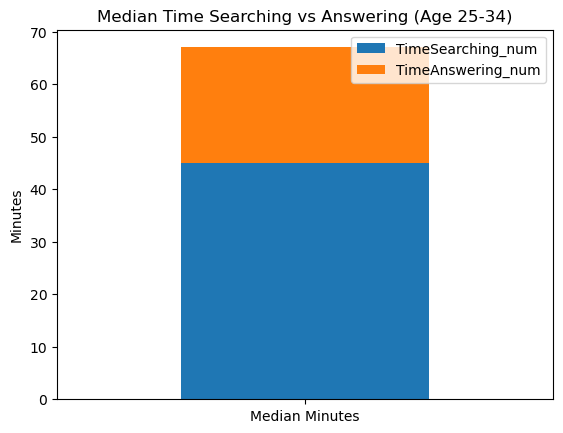

In [293]:
time_map = {
    'Less than 15 minutes a day': 7,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'More than 120 minutes a day': 150
}

t_t['TimeSearching_num'] = t_t['TimeSearching'].map(time_map)
t_t['TimeAnswering_num'] = t_t['TimeAnswering'].map(time_map)
median_values = t_t[['TimeSearching_num','TimeAnswering_num']].median()
print(median_values)
median_df = median_values.to_frame(name='Median Minutes')
median_df.T.plot(kind='bar', stacked=True)

plt.ylabel('Minutes')
plt.title('Median Time Searching vs Answering (Age 25-34)')
plt.xticks(rotation=0)

plt.show()


In [296]:
QUERY=""" 
SELECT Age, CompTotal 
FROM main 
WHERE Age IN ('45-54 years old','55-64 years old')
"""
a_c=pd.read_sql_query(QUERY, conn) 
a_c

,Age,CompTotal
0,45-54 years old,110000.0
1,45-54 years old,110000.0
2,45-54 years old,110000.0
3,45-54 years old,110000.0
4,45-54 years old,110000.0
...,...,...
8819,45-54 years old,110000.0
8820,45-54 years old,110000.0
8821,55-64 years old,110000.0
8822,45-54 years old,110000.0


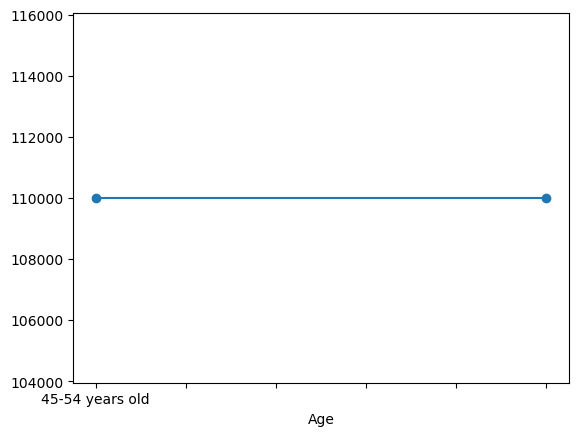

In [297]:
median_comp = a_c.groupby('Age')['CompTotal'].median()

median_comp.plot(kind='line', marker='o')
plt.show()

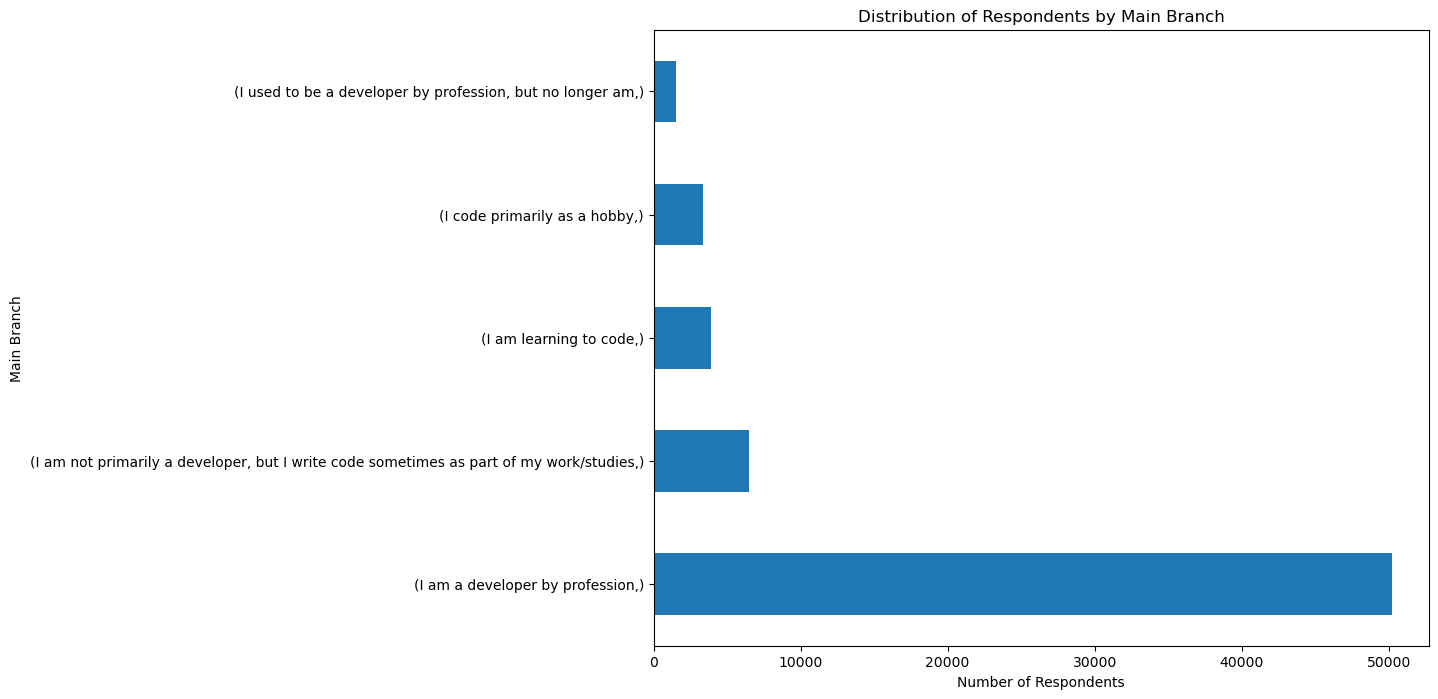

In [298]:
QUERY=""" 
SELECT MainBranch FROM main
""" 
branch_counts=pd.read_sql_query(QUERY, conn) 
branch_counts = branch_counts.value_counts().head(15)
plt.figure(figsize=(10,8))
branch_counts.plot(kind='barh')

plt.title('Distribution of Respondents by Main Branch')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')

plt.show()

In [299]:
conn.close()